In [1]:
x = 5
print(x)

5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

plt.style.use('seaborn-v0_8-whitegrid')


In [3]:
df = pd.read_csv('../data/raw/developer-survey-2025.csv', low_memory=False) # low memory is always defaulted to true

print(f"shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [4]:
list(df.columns[165:]) # 172 - 165 show the last columns

['AIAgentObsWrite',
 'AIAgentExternal',
 'AIAgentExtWrite',
 'AIHuman',
 'AIOpen',
 'ConvertedCompYearly',
 'JobSat']

In [5]:
df.tail()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
49186,49187,I code primarily as a hobby,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49187,49188,I am a developer by profession,45-54 years old,Some college/university study without earning a degree,Employed,"Caring for dependents (children, elderly, etc.)",25.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types),"Yes, I learned how to use AI-enabled tools required for my job or to benefit...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49188,49189,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,None of the above,17.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps;Videos (not associated with specific onl...,31.0,"Architect, software or solutions","10,000 or more employees",People manager,"Hybrid (some in-person, leans heavy to flexibility)","Yes, I endorsed a tool that was open-source and is currently used by more th...",Personal Project,9.0,2.0,1.0,5.0,3.0,7.0,8.0,...,Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,AI agents have increased my productivity.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0
49189,49190,I am a developer by profession,25-34 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Independent contractor, freelancer, or self-employed",None of the above,2.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Videos (not associated with specific online course or certification);Technic...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49190,49191,"I am not primarily a developer, but I write code sometimes as part of my wor...",18-24 years old,Some college/university study without earning a degree,Student,Attending school (full-time),NaN,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,6.0,Student,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
target_col = 'ConvertedCompYearly'

print(f"Target Column present: {target_col in df.columns}")

Target Column present: True


In [7]:
salary_available = df[target_col].notna().sum()

salary_missing = df[target_col].isna().sum() # not available

print(f"Rows with salary available {salary_available}")
print(f"Rows with salary missing {salary_missing}")   # 25244
print(f"Coverage {salary_available/len(df) * 100:.1f}%")  # 48.7

Rows with salary available 23947
Rows with salary missing 25244
Coverage 48.7%


In [8]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

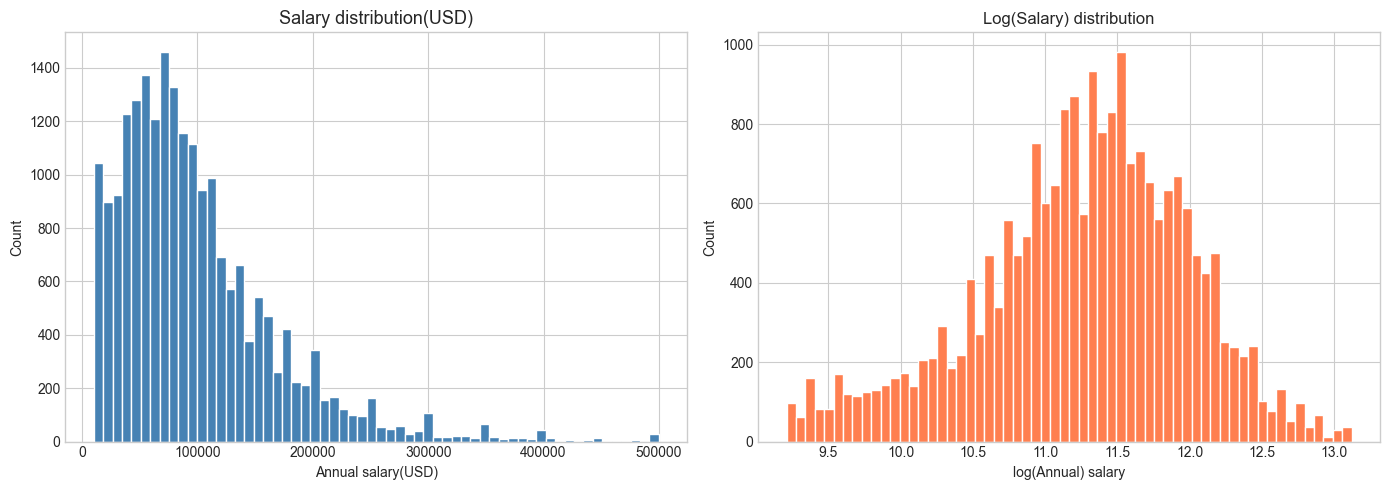

Median salary: $81,870
Mean salary: $98,572


In [9]:
salary_df = df[df[target_col].between(10000, 500000)]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1 - rows, 2 - columns 
 
#raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')
 
#log-scale distribution  - helps transform a big figure to be abit smaller and vice verser
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=150)
plt.show()
 
print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')

In [10]:
# Explore the selected features.
features = ['Country', 'YearsCode', 'EdLevel', 'Employment', 'LanguageHaveWorkedWith']
 
for col in features:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100 # helps check the missing percentage.
        unique_count = df[col].nunique() # nunique - returns the no. of unique items(int) in that object, unique() returns the actual unique items(usual an array).
 
        print(f"Column: {col}")
        print(f"Missing: {missing_pct} %")
        print(f"Unique values in {col}: {unique_count}")
        print("Top 5 values")
        print(df[col].value_counts().head().to_string)
        print()

Column: Country
Missing: 27.96039926002724 %
Unique values in Country: 177
Top 5 values
<bound method Series.to_string of Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Name: count, dtype: int64>

Column: YearsCode
Missing: 12.500254111524466 %
Unique values in YearsCode: 78
Top 5 values
<bound method Series.to_string of YearsCode
10.0    3108
15.0    2540
20.0    2497
5.0     2267
8.0     2113
Name: count, dtype: int64>

Column: EdLevel
Missing: 2.118273667947389 %
Unique values in EdLevel: 8
Top 5 values
<bound method Series.to_string of EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20278
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12

In [11]:
df_sal = df[df[target_col].between(10_100, 400_000)].copy() # .between returns a boolean series

top_countries = df_sal['Country'].value_counts().head(15).index # the .index removes the counts
top_countries

Index(['United States of America', 'Germany',
       'United Kingdom of Great Britain and Northern Ireland', 'France',
       'Canada', 'India', 'Netherlands', 'Italy', 'Australia', 'Spain',
       'Poland', 'Brazil', 'Sweden', 'Ukraine', 'Switzerland'],
      dtype='str', name='Country')

In [12]:
df_sal = df[df[target_col].between(10_100, 400_000)].copy() # .between returns a boolean series

top_countries = df_sal['Country'].value_counts().head(15)
top_countries

Country
United States of America                                4950
Germany                                                 2049
United Kingdom of Great Britain and Northern Ireland    1449
France                                                   996
Canada                                                   888
India                                                    702
Netherlands                                              595
Italy                                                    567
Australia                                                556
Spain                                                    541
Poland                                                   528
Brazil                                                   512
Sweden                                                   448
Ukraine                                                  442
Switzerland                                              402
Name: count, dtype: int64

In [13]:
df_sal

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantial addition to the tech stack",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,...,Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI agents have reduced the time sp...,AI agents have helped me automate repetitive tasks.;AI agents have improved ...,NaN,NaN,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,The cost of using certain AI agent platforms is a barrier.;I have concerns a...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibility)",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,...,Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn how to use AI agents effective...,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to fully understand something;Wh...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",None of the above,10.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Videos (not assoc...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps;Technical documentation (is generated fo...,12.0,"Developer, front-end",NaN,NaN,NaN,No,Work,12.0,2.0,3.0,7.0,5.0,10.0,13.0,...,"Yes, somewhat",Software engineering,Multi-platform search enablement,AI agents have increased my productivity.;AI agents have helped me automate ...,AI agents have improved the quality of my code.;AI agents have helped me sol...,AI agents have improved collaboration within my team.,NaN,NaN,It takes significant time and effort to learn how to use AI ag

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15020\4139609280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


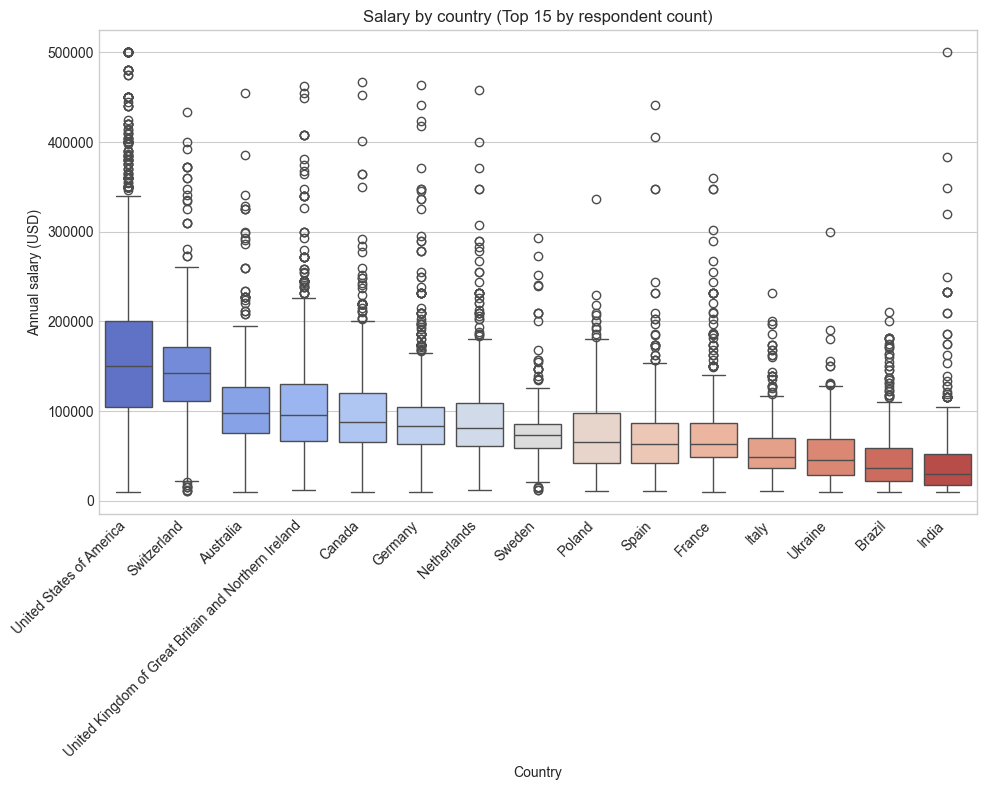

In [14]:
#visualize salary by country
# only keeps rows with salary

df_sal = df[df[target_col].between(10_000, 500_000)].copy()  # returns a series of T and F and then it save the the copy of the Ts
 
top_countries = df_sal['Country'].value_counts().head(15).index
country_data = df_sal[df_sal['Country'].isin(top_countries)]


plt.figure(figsize=(10, 8))
order= country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index
 
sns.boxplot(
    data=country_data,
    x = 'Country', y= target_col,
    order = order,
    palette='coolwarm'
)
 
plt.xticks(rotation=45, ha='right')
plt.title('Salary by country (Top 15 by respondent count)')
plt.ylabel('Annual salary (USD)')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png', dpi=300)
 
plt.show()

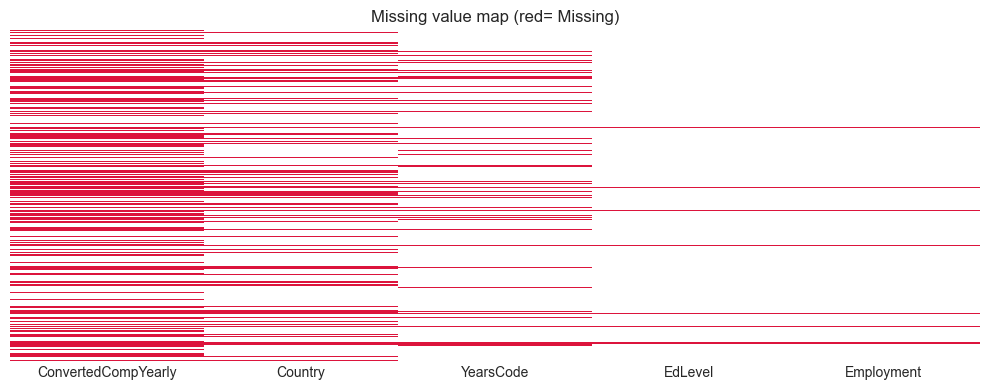

In [15]:
selected_cols = [target_col, 'Country', 'YearsCode', 'EdLevel', 'Employment']
available_cols = [c for c in selected_cols if c in df.columns]  # checks and save the column if the col is in, (helps us avoid failures)
 
missing_df = df[available_cols].isna()
 
plt.figure(figsize=(10, 4))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state=42), # we are picking a subset of 1000 rows,  not more than 1k
            cbar=False, yticklabels=False, xticklabels=True,
            cmap=['white', 'crimson'])
plt.title('Missing value map (red= Missing)')
plt.tight_layout()
plt.show()

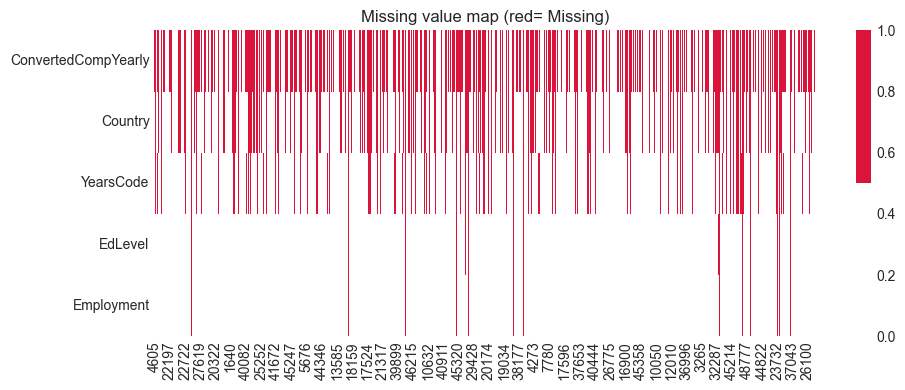

In [16]:
# just for the sake to see the transposed.
selected_cols = [target_col, 'Country', 'YearsCode', 'EdLevel', 'Employment']
available_cols = [c for c in selected_cols if c in df.columns]  # checks and save the column if the col is in, (helps us avoid failures)
 
missing_df = df[available_cols].isna()
 
plt.figure(figsize=(10, 4))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state=42).T, # Transposed view of columns            cbar=False, yticklabels=False, xticklabels=True,
            cmap=['white', 'crimson'])
plt.title('Missing value map (red= Missing)')
plt.tight_layout()
plt.show()

In [17]:
df["YearsCode"].unique()

array([ 14.,  10.,  12.,   5.,  22.,  20.,  13.,  30.,  15.,   9.,   6.,
        nan,   3.,  40.,   8.,  45.,  35.,  11.,   7.,  47.,  41.,  36.,
        23.,  29.,  26.,  25.,  38.,  21.,  19.,  18.,  16.,   4.,  17.,
        42.,  27.,  24.,   2.,  28.,  37.,  32.,   1.,  39.,  53.,  33.,
        50.,  48.,  44.,  31.,  46.,  43.,  49.,  52.,  34.,  51.,  58.,
        57.,  54.,  63.,  60.,  55.,  65., 100.,  99.,  56.,  69.,  90.,
        61.,  67.,  75.,  64.,  98.,  68.,  89.,  62.,  78.,  70.,  76.,
        82.,  59.])

In [18]:
df["YearsCode"].info()

<class 'pandas.Series'>
RangeIndex: 49191 entries, 0 to 49190
Series name: YearsCode
Non-Null Count  Dtype  
--------------  -----  
43042 non-null  float64
dtypes: float64(1)
memory usage: 384.4 KB


In [19]:
df["EdLevel"].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str

In [20]:
df["Employment"].unique()

<ArrowStringArray>
[                                            'Employed',
 'Independent contractor, freelancer, or self-employed',
                                              'Student',
                                              'Retired',
                                         'Not employed',
                                  'I prefer not to say',
                                                    nan]
Length: 7, dtype: str

In [21]:
df["LanguageHaveWorkedWith"].unique()

<ArrowStringArray>
[                                                                     'Bash/Shell (all shells);Dart;SQL',
                                                                                                  'Java',
                                                                   'Dart;HTML/CSS;JavaScript;TypeScript',
                                                                                       'Java;Kotlin;SQL',
 'C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;PowerShell;Python;SQL;TypeScript;VBA;Visual Basic (.Net)',
                                                                                            'Java;Scala',
                                                                                 'JavaScript;TypeScript',
                                     'Bash/Shell (all shells);HTML/CSS;JavaScript;Python;SQL;TypeScript',
                                                                                     'Java;Python;Scala',
                           

In [22]:
df["Country"].unique()

<ArrowStringArray>
[                 'Ukraine',              'Netherlands',
                    'India',                  'Georgia',
                'Australia',                   'Greece',
                  'Germany',               'Bangladesh',
                   'Brazil', 'United States of America',
 ...
                   'Gambia',                   'Malawi',
                    'Niger',                  'Lesotho',
               'San Marino',                 'Djibouti',
                  'Burundi',               'Cape Verde',
                    'Palau',                   'Guinea']
Length: 178, dtype: str

In [23]:
# OS helps do things like change directory
# sys helps define the defaults or our files

# adding /scr to path to allow us to import our modules
sys.path.insert(0, os.path.dirname('../src/')) # best practice is __file__

import os
import sys 

from preprocessing import load_and_clean, get_feature_columns, TARGET

df = load_and_clean('../data/raw/developer-survey-2025.csv')

df.to_csv('../data/cleaned/processed_data.csv', index=False)


NameError: name 'sys' is not defined

In [ ]:
df["WorkExp"].unique()

In [ ]:
df['Devtype'].unique()

In [ ]:
df_subset = pd.read_csv('../data/cleaned/processed-data.csv')

In [ ]:
df_subset.info()

In [ ]:
df_subset["Industry"].value_counts().head(10)

# Feature Selection and decisions.
# create a preprocessing file .py on the scr.
#  function ya kuclean various columns you can have things like a list or pandas , 
import pandas as pd
def cleanCountry(series: pd.Series):
    pass
this is preprocessing.py  under the scr

1. for countries even target encode wont help that much you pick the top 15 countries then categories the rest as other. then proceed to do your encoding
(the no. of responses who answered the quostionaire are less)
2. for languages count the languages that a person has then save that and have a new column like languages count define a function of this (separate by ; and )
3. Clean the emplyoments just make sure everything is either in lower/upper case then Then have a function called def 
4. 


5. The education levels like masters degree just change it to masters only. reduce the wordings and the spacings. 
6. years code  convert them to floating point like less than 1yr is 0.5
then save this under clean. 

then make the pipeline that takes our cleaned data, for working on missing etc
    
    # how to call all this files inside our main file. we pass our data to clean (some impoorts are from the project itself)
    pipeline, training 
model.py under ScribdDocument= from file name preprocessing import cleanCountry

blue - sucess
grey ongoing
red error when running the model.py 


Feature selection and cleaning: 1. Feature decisions - which features do want to use and why. is cleaning needed? 2. Create a preprocessing file, ie src/preprocessing.py,
have several cleaning functions, then after cleaning the data, 3. Pipeline and model training

--------Version 2-------------------
# Changes to make so as to improve model r2 (changes being made to the preprocesisng.py)
 
Originally -> 5 features, raw salary, OHE, basic XGBoost.
 
1. More features - We've added 10 features from raw data but are not processed.
2. log-transformed the salary column - now called, 'log_salary'.
3. Tune XGBoost params.n_estimators, max_depth, learning_rate, Regularization, 'reg_alpha' - L1 regularization (feature selection), 'reg_lambda' - L2 Regularization (weight shrinkage).
4. Target encoding - Country/ DevType/Industry.
5. Ordinal encoding - EdLevel/ RemoteWork/ Age/OrgSize
6.Onehot then drop first for individual interaction(ICorPM)
7. Interaction features.
Python
    def add_intercation_features(df):
        df['yearsCode_sq'] = df['YearsCode'] ** 2
        df['WorkExp_sq'] = df['WorkExp'] ** 2
        df['Exp_ratio'] = df['WorkExp']/ (df['YearsCode'] + 1)
        df['Tech_breadth'] = (df['LanguageCount'] + df['DatabaseCount'] + df['PlatformCount']).fillna(0)
        return df
		
the function should be before load_and_clean then call it before drop columns where all features are missing

you can later drop the features that are highly correlated eg languagecount, databasecount, etc
after making these changes you should get accuracy about 55


In [ ]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantial addition to the tech stack",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,...,Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI agents have reduced the time sp...,AI agents have helped me automate repetitive tasks.;AI agents have improved ...,NaN,NaN,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,The cost of using certain AI agent platforms is a barrier.;I have concerns a...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibility)",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,...,Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn how to use AI agents effective...,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to fully understand something;Wh...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",None of the above,10.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Videos (not assoc...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps;Technical documentation (is generated fo...,12.0,"Developer, front-end",NaN,NaN,NaN,No,Work,12.0,2.0,3.0,7.0,5.0,10.0,13.0,...,"Yes, somewhat",Software engineering,Multi-platform search enablement,AI agents have increased my productivity.;AI agents have helped me automate ...,AI agents have improved the quality of my code.;AI agents have helped me sol...,AI agents have improved collaboration within my team.,NaN,NaN,It takes significant time and effort to learn how to use AI ag

In [ ]:
df_sal["Country"]

0                         Ukraine
1                     Netherlands
2                         Ukraine
3                         Ukraine
4                         Ukraine
                   ...           
49084    United States of America
49088    United States of America
49106                South Africa
49121                      France
49122                       Italy
Name: Country, Length: 21203, dtype: str

In [ ]:
# how many missing , correlation, on the py pick the , column transformer, save. .ignore pull it first then push it
# how to pass columnTransformer to your pipeline


In [ ]:
df_clean = df[features + [target_col]].dropna()

In [ ]:
df_clean = df[['Country','YearsCode', 'EdLevel', 'Employment', 'LanguageHaveWorkedWith','ConvertedCompYearly']]

In [ ]:
df_clean.info()   # 49191

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 35437 non-null  str    
 1   YearsCode               43042 non-null  float64
 2   EdLevel                 48149 non-null  str    
 3   Employment              48339 non-null  str    
 4   LanguageHaveWorkedWith  31671 non-null  str    
 5   ConvertedCompYearly     23947 non-null  float64
dtypes: float64(2), str(4)
memory usage: 7.2 MB


In [ ]:
df_clean.to_csv('../data/cleaned/cleaned_results.csv')

In [ ]:
df_clean.shape

(49191, 6)